# Assignment 3: Prompt Engineering Lab

Roger Kutyna
https://github.com/rkutyna/MSIT3103-GenAI-assignments/blob/main/assignment_3

In [1]:
# Generated by GPT-5 (high reasoning) via Windsurf 9/18/25
# Prompt: My jupyter notebooks are generating sideways scrolling elements for long strings of text, 
# how can I make the text wrap instead


from IPython.display import display, HTML
import html

def show_wrapped(text: str):
    display(HTML(
        f"""
        <div style="
            white-space: pre-wrap;
            overflow-wrap: anywhere;
            word-break: break-word;
            max-width: 100%;
            font-family: ui-monospace, Menlo, Monaco, Consolas, 'Courier New', monospace;
        ">{html.escape(text)}</div>
        """
    ))

In [2]:

# Taken from assignment template

import json, os, subprocess, time, uuid, textwrap
from dataclasses import dataclass, asdict
from typing import List, Dict

RESULTS_DIR = "a3_outputs"
os.makedirs(RESULTS_DIR, exist_ok=True)

def ollama_run(model: str, prompt: str, options: Dict=None, timeout: int = 120) -> str:
    """Run a prompt through a local Ollama model via subprocess and return the text.

    Requires Ollama to be installed and available on PATH.

    """
    cmd = ["ollama", "run", model]
    if options:
        # Ollama CLI supports options via the JSON API; here we keep CLI simple.
        # For advanced options, consider using `ollama generate -m model -p prompt --options '{...}'` pattern.
        pass
    proc = subprocess.run(cmd, input=prompt.encode("utf-8"), stdout=subprocess.PIPE, stderr=subprocess.PIPE, timeout=timeout)
    if proc.returncode != 0:
        raise RuntimeError(f"Ollama error: {proc.stderr.decode('utf-8', errors='ignore')}")
    return proc.stdout.decode("utf-8", errors="ignore")

@dataclass
class Trial:
    step: str                 # basic / structured / fewshot / cot
    task_id: str              # arbitrary id of the task/question
    prompt: str
    response: str
    meta: Dict

def save_trials(trials: List[Trial], path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump([asdict(t) for t in trials], f, ensure_ascii=False, indent=2)
    print(f"Saved {len(trials)} trials to {path}")


In [3]:
# Context generated by GPT-5 (Custom GPT - D810 Manual Explorer) 9/18/25
# Prompt: Can you come up with a blurb about this camera?

CONTEXT="""
The Nikon D810 is a full-frame DSLR designed for professionals who demand detail and versatility. 
It delivers 36.3 megapixel stills with no optical low-pass filter, records full HD 1080/60p video, and offers broad tonal range with 14-bit RAW output. 
Users can refine every shot with in-camera Picture Controls, bracketing, and advanced metering modes.
Core features include: ISO 64–12,800 (expandable to 32–51,200), a 51-point Multi-CAM 3500FX AF system with Group Area AF, 5 fps burst shooting (7 fps in DX crop with grip), and an electronic front-curtain shutter that minimizes vibration.
Photographers often track key performance metrics: dynamic range in challenging light, autofocus tracking precision, continuous shooting buffer depth, and low-light noise performance.
""".strip()

# Tasks generated by GPT-5 (Custom GPT - D810 Manual Explorer) 9/18/25
# Prompt: Can you come up with 4 tasks related to this blurb? 
# Please do it in a similar style to this text: (Text from assignment task list)

TASKS=[
    {"id": "t1", "question": "Summarize the core strengths of the Nikon D810 in one paragraph."},
    {"id": "t2", "question": "List three performance metrics photographers track and explain why they matter."},
    {"id": "t3", "question": "Suggest an exercise for a user to understand the relationship of ISO, Aperature, and Shutter speed using the Nikon D810"},
    {"id": "t4", "question": "Write a short FAQ answer: 'What is the benefit of the electronic front-curtain shutter?'"}
]

print(CONTEXT)
print("\nTasks:")
for t in TASKS:
    print("-", t["id"] + ":", t["question"])

The Nikon D810 is a full-frame DSLR designed for professionals who demand detail and versatility. 
It delivers 36.3 megapixel stills with no optical low-pass filter, records full HD 1080/60p video, and offers broad tonal range with 14-bit RAW output. 
Users can refine every shot with in-camera Picture Controls, bracketing, and advanced metering modes.
Core features include: ISO 64–12,800 (expandable to 32–51,200), a 51-point Multi-CAM 3500FX AF system with Group Area AF, 5 fps burst shooting (7 fps in DX crop with grip), and an electronic front-curtain shutter that minimizes vibration.
Photographers often track key performance metrics: dynamic range in challenging light, autofocus tracking precision, continuous shooting buffer depth, and low-light noise performance.

Tasks:
- t1: Summarize the core strengths of the Nikon D810 in one paragraph.
- t2: List three performance metrics photographers track and explain why they matter.
- t3: Suggest an exercise for a user to understand the rel

In [4]:
# Taken from assignment file

MODEL = "llama3.2:1b"

basic_trials = []
i=0
for task in TASKS:
    prompt = f"""
You are a helpful assistant.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    basic_trials.append(Trial(step="basic", task_id=task["id"], prompt=prompt, response=resp, meta={}))
    show_wrapped(task['question'])
    show_wrapped(basic_trials[i].response)
    i+=1

save_trials(basic_trials, os.path.join(RESULTS_DIR, "step1_basic.json"))

Saved 4 trials to a3_outputs/step1_basic.json


In [5]:
# Taken from assignment file

MODEL = "llama3.2:1b"

basic_trials = []
i=0
for task in TASKS:
    prompt = f"""
You are a helpful assistant. Return the answer in **strict JSON** with keys:
- "answer": string
- "supporting_facts": list of short strings derived from the context
- "confidence": number in [0,1]

Context:
{CONTEXT}

Question:
{task['question']}

If something is unknowable from the context, set "confidence": 0 and use an empty "supporting_facts".
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    basic_trials.append(Trial(step="structured", task_id=task["id"], prompt=prompt, response=resp, meta={}))
    show_wrapped(task['question'])
    show_wrapped(basic_trials[i].response)
    i+=1

save_trials(basic_trials, os.path.join(RESULTS_DIR, "step2_structured.json"))

Saved 4 trials to a3_outputs/step2_structured.json


In [6]:
# Questions and answer examples generated by GPT-5 9/18/25
# Prompt: Can you generate some example questions and answers 
# to improve few shot prompting, based on the following text:

FEW_SHOT_EXAMPLES = [
    {
        "q": "What is the resolution of the Nikon D810’s sensor?",
        "a": "The Nikon D810 has a 36.3 megapixel full-frame sensor."
    },
    {
        "q": "Why does the D810 omit an optical low-pass filter?",
        "a": "Removing the optical low-pass filter allows the camera to capture sharper detail, though it can slightly increase the risk of moiré patterns in certain textures."
    },
    {
        "q": "What video formats can the D810 record?",
        "a": "It records full HD 1080p video at up to 60 frames per second."
    },
    {
        "q": "What autofocus system does the D810 use?",
        "a": "It uses the 51-point Multi-CAM 3500FX AF system, which includes Group Area AF for improved subject tracking."
    },
    {
        "q": "How does the D810 perform in low-light conditions?",
        "a": "Its native ISO range is 64–12,800 (expandable to 32–51,200), giving flexibility in dim lighting while maintaining relatively low noise."
    },
]

def render_fewshot_block(examples):
    parts = ["You are a helpful assistant. Here are some QA examples:"]
    for ex in examples:
        parts.append(f"Q: {ex['q']}\nA: {ex['a']}")
    return "\n\n".join(parts)

fewshot_prefix = render_fewshot_block(FEW_SHOT_EXAMPLES)
i=0
fewshot_trials = []
for task in TASKS:
    prompt = f"""
{fewshot_prefix}

Now answer the new question using the context below.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    fewshot_trials.append(Trial(step="fewshot", task_id=task["id"], prompt=prompt, response=resp, meta={"k": len(FEW_SHOT_EXAMPLES)}))
    show_wrapped(task['question'])
    show_wrapped(fewshot_trials[i].response)
    i+=1
save_trials(fewshot_trials, os.path.join(RESULTS_DIR, "step3_fewshot.json"))


Saved 4 trials to a3_outputs/step3_fewshot.json


In [7]:
# Code taken from assignment file


cot_trials = []
i=0
for task in TASKS:
    prompt = f"""
You are a helpful assistant. Let's think step by step and show context used and reasoning before the final answer.
Use the context to avoid hallucinations. **Provide a short final answer at the end under 'Final Answer: ...'**.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    cot_trials.append(Trial(step="cot", task_id=task["id"], prompt=prompt, response=resp, meta={"cot": True}))
    show_wrapped(task['question'])
    show_wrapped(cot_trials[i].response)
    i+=1
save_trials(cot_trials, os.path.join(RESULTS_DIR, "step4_cot.json"))


Saved 4 trials to a3_outputs/step4_cot.json


In [8]:
# Code taken from assignment file
import json, glob, pandas as pd

def load_trials(pattern):
    rows = []
    for path in sorted(glob.glob(pattern)):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        for item in data:
            rows.append({
                "file": os.path.basename(path),
                "step": item["step"],
                "task_id": item["task_id"],
                "task_num": int(item['task_id'][1]), 
                "prompt": item["prompt"],
                "response": item["response"],
            })
    return pd.DataFrame(rows)

df = load_trials(os.path.join(RESULTS_DIR, "step*.json"))
df.head()


,file,step,task_id,task_num,prompt,response
0,step1_basic.json,basic,t1,1,You are a helpful assistant.\n\nContext:\nThe ...,The Nikon D810 is a versatile and feature-rich...
1,step1_basic.json,basic,t2,2,You are a helpful assistant.\n\nContext:\nThe ...,"Based on the Nikon D810's features, here are t..."
2,step1_basic.json,basic,t3,3,You are a helpful assistant.\n\nContext:\nThe ...,To help you understand the relationship betwee...
3,step1_basic.json,basic,t4,4,You are a helpful assistant.\n\nContext:\nThe ...,Here's a short FAQ answer:\n\nQ: What is the b...
4,step2_structured.json,structured,t1,1,You are a helpful assistant. Return the answer...,"```\n{\n ""answer"": ""The Nikon D810 has severa..."


In [9]:
df.iloc[4]['task_id']

't1'

In [10]:
MODEL = "gemma3:12b"

rating_trials = []
for i in range(len(df)):
    task = TASKS[df.iloc[i]['task_num']-1]
    response = df.iloc[i]['response']
    prompt = f"""
You are a response grader. Grade the responses based on the answer to the given question in relation to the 
context. Return the grades in **strict JSON** with keys:
- "correctness": number in [0,5]
- "completeness": number in [0,5]
- "confidence": number in [0,5]
- "notes": general review and comments on the response

Context:
{CONTEXT}

Question:
{task['question']}

Response:
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    rating_trials.append(Trial(step="grader", task_id=task["id"], prompt=prompt, response=resp, meta={}))
    print(i, end=", ")

save_trials(rating_trials, os.path.join(RESULTS_DIR, "ratings.json"))

0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, Saved 16 trials to a3_outputs/ratings.json


In [11]:
# Generated by GPT-5 (high reasoning) via Windsurf 9/18/25
# Prompt: @assignment3_rkutyna.ipynb#X13sZmlsZQ%3D%3D#L1-30 If I have this code to 
# have gemma grade previous responses and have it return grades in json format, how can 
# I then parse this json to add these grades as to the dataframe?

import os, json, re
import pandas as pd

def extract_json_blob(text: str):
    if not isinstance(text, str):
        return None
    s = text.strip()
    # Strip code fences like ```json ... ```
    if s.startswith("```"):
        s = re.sub(r"^```(?:json)?\s*", "", s, flags=re.IGNORECASE)
        s = re.sub(r"\s*```$", "", s)
    # Try direct JSON
    try:
        return json.loads(s)
    except Exception:
        # Fallback: pull the first {...} block
        m = re.search(r"\{.*\}", s, flags=re.DOTALL)
        if m:
            try:
                return json.loads(m.group(0))
            except Exception:
                return None
    return None

ratings_path = os.path.join(RESULTS_DIR, "ratings.json")
with open(ratings_path, "r", encoding="utf-8") as f:
    trials = json.load(f)

# Parse each trial["response"] into a dict of grades
rows = []
for t in trials:
    js = extract_json_blob(t.get("response", ""))
    rows.append({
        "task_id": t.get("task_id"),
        "correctness_raw": js.get("correctness") if js else None,
        "completeness_raw": js.get("completeness") if js else None,
        "confidence_raw": js.get("confidence") if js else None,
        "notes": js.get("notes") if js else None,
    })

grades = pd.DataFrame(rows)

# Normalize to 0–1 (handles 0–100 too) and also provide 0–5 if you want to compare with earlier rubric
def to_float(x):
    try:
        return float(x)
    except Exception:
        return None

def normalize01(x):
    v = to_float(x)
    if v is None:
        return None
    return v/100.0 if v > 1 else v

# for col in ["correctness_raw", "completeness_raw", "confidence_raw"]:
#     base = col.replace("_raw", "")
#     grades[base + "_0_1"] = grades[col].apply(normalize01)
#     grades[base + "_0_5"] = grades[base + "_0_1"].apply(lambda v: v*5 if v is not None else None)

# Attach to df by row position (assumes same order/length)
assert len(grades) == len(df), "ratings.json length does not match df"
df = df.reset_index(drop=True)
grades = grades.reset_index(drop=True)
df = pd.concat([df, grades], axis=1)

df.head()

,file,step,task_id,task_num,prompt,response,task_id,correctness_raw,completeness_raw,confidence_raw,notes
0,step1_basic.json,basic,t1,1,You are a helpful assistant.\n\nContext:\nThe ...,The Nikon D810 is a versatile and feature-rich...,t1,5,5,5,The response accurately and comprehensively su...
1,step1_basic.json,basic,t2,2,You are a helpful assistant.\n\nContext:\nThe ...,"Based on the Nikon D810's features, here are t...",t2,4,4,5,The response correctly identifies three perfor...
2,step1_basic.json,basic,t3,3,You are a helpful assistant.\n\nContext:\nThe ...,To help you understand the relationship betwee...,t3,4,4,5,The response provides a reasonable exercise re...
3,step1_basic.json,basic,t4,4,You are a helpful assistant.\n\nContext:\nThe ...,Here's a short FAQ answer:\n\nQ: What is the b...,t4,5,5,5,The response accurately and concisely explains...
4,step2_structured.json,structured,t1,1,You are a helpful assistant. Return the answer...,"```\n{\n ""answer"": ""The Nikon D810 has severa...",t1,4,5,5,The response accurately identifies several cor...


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   file              16 non-null     object
 1   step              16 non-null     object
 2   task_id           16 non-null     object
 3   task_num          16 non-null     int64 
 4   prompt            16 non-null     object
 5   response          16 non-null     object
 6   task_id           16 non-null     object
 7   correctness_raw   16 non-null     int64 
 8   completeness_raw  16 non-null     int64 
 9   confidence_raw    16 non-null     int64 
 10  notes             16 non-null     object
dtypes: int64(4), object(7)
memory usage: 1.5+ KB


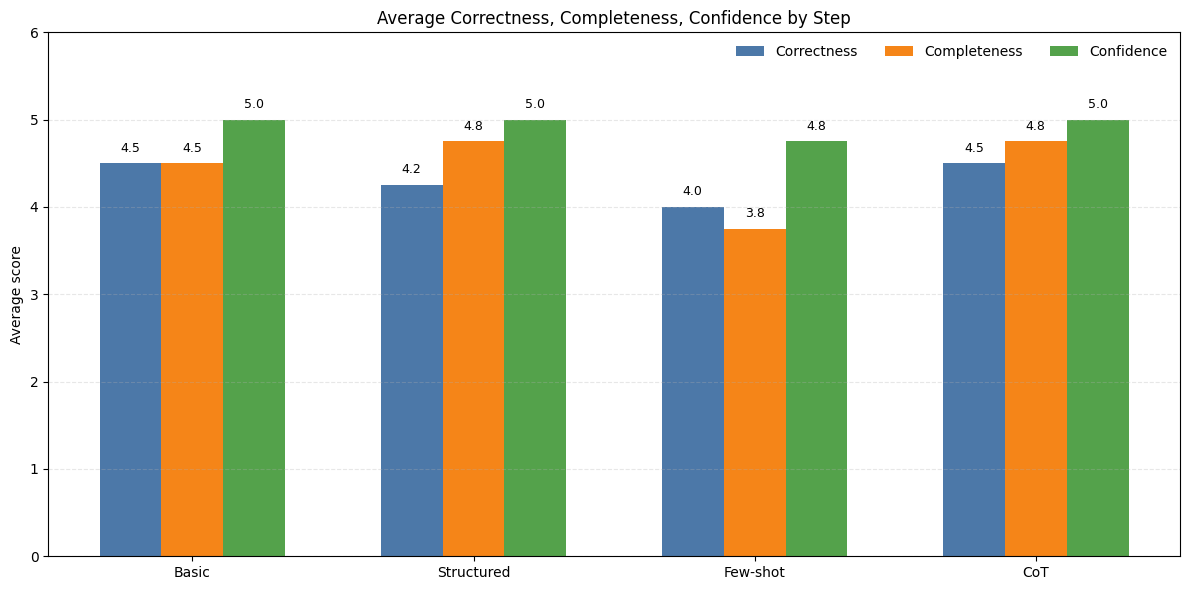

In [ ]:
# Genereated by GPT-5 (high reasoning) via Windsurf 9/18/25
# Prompt: Please generate code to create a 2x2 array of bar charts, 
# each with 3 bars representing the average correctness, completeness, and confidence. 
# Each bar chart should be the averages by step (basic, structured, few shot, cot). 
# Here is the info for the dataframe that you should reference:
# <class 'pandas.core.frame.DataFrame'>
# RangeIndex: 16 entries, 0 to 15
# Data columns (total 11 columns):
#  #   Column            Non-Null Count  Dtype 
# ---  ------            --------------  ----- 
#  0   file              16 non-null     object
#  1   step              16 non-null     object
#  2   task_id           16 non-null     object
#  3   task_num          16 non-null     int64 
#  4   prompt            16 non-null     object
#  5   response          16 non-null     object
#  6   task_id           16 non-null     object
#  7   correctness_raw   16 non-null     int64 
#  8   completeness_raw  16 non-null     int64 
#  9   confidence_raw    16 non-null     int64 
#  10  notes             16 non-null     object
# dtypes: int64(4), object(7)
# memory usage: 1.5+ KB

# Prompt 2: @assignment3_rkutyna.ipynb#X16sZmlsZQ%3D%3D#L1-93 
# Can you actually change this to be one chart with gour groups of three bars 

import numpy as np
import matplotlib.pyplot as plt

# Make a copy to avoid mutating your original df
df_plot = df.copy()

# Normalize step names to a canonical set
def canonical_step(s):
    s = (s or "").strip().lower()
    s = s.replace(" ", "").replace("_", "-")
    if s in ("basic",):
        return "basic"
    if s in ("structured",):
        return "structured"
    if s in ("fewshot", "few-shot"):
        return "fewshot"
    if s in ("cot", "chainofthought", "chain-of-thought"):
        return "cot"
    return s

df_plot["step_key"] = df_plot["step"].apply(canonical_step)

metrics = ["correctness_raw", "completeness_raw", "confidence_raw"]
metric_labels = ["Correctness", "Completeness", "Confidence"]
order = ["basic", "structured", "fewshot", "cot"]
titles = {"basic": "Basic", "structured": "Structured", "fewshot": "Few-shot", "cot": "CoT"}

# Compute per-step averages and keep only steps that exist
agg = (
    df_plot.groupby("step_key")[metrics]
    .mean()
    .reindex(order)
    .dropna(how="all")
)

steps = list(agg.index)
x = np.arange(len(steps))  # group centers on x-axis

# Bar layout
n_metrics = len(metrics)
width = 0.22  # bar width within each group
offsets = [(j - (n_metrics - 1) / 2) * width for j in range(n_metrics)]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#4C78A8", "#F58518", "#54A24B"]

# Determine a reasonable y-limit (works for 0–5 or 0–100 scales)
ymax = float(np.nanmax(agg.values)) if agg.size else 5.0
ylim = (0, 6) if ymax <= 5 else (0, 110)

bars_by_metric = []
for j, (metric, label) in enumerate(zip(metrics, metric_labels)):
    vals = agg[metric].values.astype(float)
    bars = ax.bar(x + offsets[j], vals, width=width, label=label, color=colors[j])
    bars_by_metric.append(bars)
    # Add value labels
    for b in bars:
        h = b.get_height()
        if np.isnan(h):
            continue
        ax.text(b.get_x() + b.get_width()/2, h + (0.1 if ylim[1] <= 6 else 2),
                f"{h:.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([titles.get(s, s.title()) for s in steps])
ax.set_ylabel("Average score")
ax.set_title("Average Correctness, Completeness, Confidence by Step")
ax.set_ylim(*ylim)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(ncol=3, frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# Code generated by GPT-5 (high reasoning) via Windsurf 9/19/25
# Prompt: Thanks, but scratch that, can you just make a table with the same data as the graph (
# average score per step for correctness, completeness, and confidence)? Here is the df again: 
# 
# <class 'pandas.core.frame.DataFrame'>
# RangeIndex: 16 entries, 0 to 15
# Data columns (total 11 columns):
#  #   Column            Non-Null Count  Dtype 
# ---  ------            --------------  ----- 
#  0   file              16 non-null     object
#  1   step              16 non-null     object
#  2   task_id           16 non-null     object
#  3   task_num          16 non-null     int64 
#  4   prompt            16 non-null     object
#  5   response          16 non-null     object
#  6   task_id           16 non-null     object
#  7   correctness_raw   16 non-null     int64 
#  8   completeness_raw  16 non-null     int64 
#  9   confidence_raw    16 non-null     int64 
#  10  notes             16 non-null     object
# dtypes: int64(4), object(7)
# memory usage: 1.5+ KB

import pandas as pd
import numpy as np

# Work on a copy
df_tbl = df.copy()

# Normalize step names
def canonical_step(s):
    s = str(s).strip().lower()
    s = s.replace("_", "-").replace(" ", "")
    if s in ("basic",):
        return "basic"
    if s in ("structured",):
        return "structured"
    if s in ("fewshot", "few-shot"):
        return "fewshot"
    if s in ("cot", "chainofthought", "chain-of-thought"):
        return "cot"
    return s

df_tbl["step_key"] = df_tbl["step"].apply(canonical_step)

order = ["basic", "structured", "fewshot", "cot"]
labels = {"basic":"Basic", "structured":"Structured", "fewshot":"Few-shot", "cot":"CoT"}

summary = (
    df_tbl.groupby("step_key")[["correctness_raw", "completeness_raw", "confidence_raw"]]
    .mean()
    .reindex(order)
    .rename(index=labels, columns={
        "correctness_raw":"Correctness",
        "completeness_raw":"Completeness",
        "confidence_raw":"Confidence"
    })
    .round(2)
    .rename_axis("Step")
    .reset_index()
)

summary  # This is the table you want
# Optionally: display(summary.style.set_caption("Average Scores by Step"))
# Optionally save:
# summary.to_csv(os.path.join(RESULTS_DIR, "avg_scores_by_step.csv"), index=False)

,Step,Correctness,Completeness,Confidence
0,Basic,4.50,4.50,5.00
1,Structured,4.25,4.75,5.00
2,Few-shot,4.00,3.75,4.75
3,CoT,4.50,4.75,5.00
